In [1]:
#%%
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
domain='d03'
#%load domain geometry  
geo_em_file = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/domain/geo_em.'+domain+'.nc'  
basepath='/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/'
gridded_data_path = basepath+'historical/variables_complete/'

# === Load land mask ===
landmask = xr.open_dataset(geo_em_file)['LANDMASK'].squeeze()
landmask = landmask.rename({'south_north': 'lat', 'west_east': 'lon'})  # ensure standard naming
if 'south_north' in landmask.coords:
    landmask = landmask.rename({'south_north': 'lat'})
if 'west_east' in landmask.coords:
    landmask = landmask.rename({'west_east': 'lon'})

landmask = landmask.values #.transpose('lon', 'lat')  # Now shape matches delta
land_mask = (landmask == 1)
ocean_mask = (landmask == 0)


## === Area weights ===
#weights = np.cos(np.deg2rad(var_hist['lat'].values))

#land_weights = weights * land_mask
#ocean_weights = weights* ocean_mask





This notebook will compute the monthly averages, plot the seasonal cylces,make bar pots of the seasona changes and compuet the standard error. 

In [2]:
import numpy as np
import xarray as xr


# ============================================================
# Helper: weighted regional mean time series
# ============================================================

def weighted_mean_timeseries(data, weights, mask):
    """
    Compute weighted spatial mean time series.

    Parameters
    ----------
    data : xarray.DataArray
        Shape: (time, lat, lon)

    weights : ndarray
        Shape: (lat, lon)

    mask : ndarray(bool)
        Shape: (lat, lon)

    Returns
    -------
    xarray.DataArray
        Shape: (time,)
    """


    w = xr.DataArray(
        weights * mask,
        dims=['lat', 'lon']
    )

    valid_weights = w.where(np.isfinite(data))

    ts = (
        (data * valid_weights).sum(dim=['lat', 'lon'])
        /
        valid_weights.sum(dim=['lat', 'lon'])
    )

    return ts


# ============================================================
# Monthly climatology + delta + propagated SEM
# ============================================================

def climatology_delta_sem(hist_ts, fut_ts, relative=False):
    """
    Compute monthly climatologies, deltas, and propagated SEM.

    Parameters
    ----------
    hist_ts : xarray.DataArray
        Monthly time series, shape: (time,)

    fut_ts : xarray.DataArray
        Monthly time series, shape: (time,)

    relative : bool
        If True:
            delta = percent change
        else:
            delta = absolute difference

    Returns
    -------
    hist_clim : ndarray(12,)
    fut_clim  : ndarray(12,)
    delta     : ndarray(12,)
    sem       : ndarray(12,)
    """

    # --------------------------------------------------------
    # Monthly climatologies
    # --------------------------------------------------------

    hist_clim = hist_ts.groupby('time.month').mean()
    fut_clim  = fut_ts.groupby('time.month').mean()

    if relative:
        delta = ((fut_clim - hist_clim) / hist_clim) * 100.0
    else:
        delta = fut_clim - hist_clim

    # --------------------------------------------------------
    # Monthly SEMs
    # --------------------------------------------------------

    hist_groups = hist_ts.groupby('time.month')
    fut_groups  = fut_ts.groupby('time.month')

    hist_sem = hist_groups.std(dim='time', ddof=1) / np.sqrt(hist_groups.count())
    fut_sem  = fut_groups.std(dim='time', ddof=1) / np.sqrt(fut_groups.count())

    # Propagated SEM
    sem = np.sqrt(hist_sem**2 + fut_sem**2)

    # --------------------------------------------------------
    # Scale SEM consistently for relative deltas
    # --------------------------------------------------------

    if relative:
        sem = (sem / np.abs(hist_clim)) * 100.0

    return (
        hist_clim.values,
        fut_clim.values,
        delta.values,
        sem.values
    )


# ============================================================
# Main driver
# ============================================================

def get_monthly_climatologies(variable, domain):

    # --------------------------------------------------------
    # Variable setup
    # --------------------------------------------------------

    if variable == "t":
        var = 'T2'
        filename = f't_{domain}_daily_newdim'
        relative = False

    elif variable == "pr":
        var = 'pr'
        filename = f'pr_{domain}_daily'
        relative = True

    elif variable == "wind":
        var = 'wspd'
        relative = True

        if domain == "d03":
            filename = 'wind_d03_daily_wspd'
        else:
            filename = f'wind_{domain}_daily'

    else:
        raise ValueError(f"Unknown variable: {variable}")

    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    basepath = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/'

    geo_em_file = (
        basepath +
        f'domain/geo_em.{domain}.nc'
    )

    hist_path = (
        basepath +
        f'historical/variables_complete/{filename}.nc'
    )

    rcp45_path = (
        basepath +
        f'rcp45/variables_complete/{filename}.nc'
    )

    rcp85_path = (
        basepath +
        f'rcp85/variables_complete/{filename}.nc'
    )

    # --------------------------------------------------------
    # Land mask
    # --------------------------------------------------------

    landmask = xr.open_dataset(geo_em_file)['LANDMASK'].squeeze()

    landmask = landmask.rename({
        'south_north': 'lat',
        'west_east': 'lon'
    })
    print('dimensions on landmask', landmask.T.dims)
    landmask = landmask.T.values

    land_mask  = (landmask == 1)
    ocean_mask = (landmask == 0)

    # --------------------------------------------------------
    # Load datasets
    # --------------------------------------------------------

    hist = xr.open_dataset(hist_path)[var]
    rcp45 = xr.open_dataset(rcp45_path)[var]
    rcp85 = xr.open_dataset(rcp85_path)[var]

    # --------------------------------------------------------
    # Rename coords if needed
    # --------------------------------------------------------

    if variable == 't':

        hist = hist.rename({
            'longitude': 'lon',
            'latitude': 'lat'
        })

        rcp45 = rcp45.rename({
            'longitude': 'lon',
            'latitude': 'lat'
        })

        rcp85 = rcp85.rename({
            'longitude': 'lon',
            'latitude': 'lat'
        })

    # --------------------------------------------------------
    # Monthly means
    # --------------------------------------------------------

    hist_ym  = hist.resample(time='1MS').mean()
    rcp45_ym = rcp45.resample(time='1MS').mean()
    rcp85_ym = rcp85.resample(time='1MS').mean()

    # --------------------------------------------------------
    # Area weights
    # --------------------------------------------------------

    weights =np.cos(np.deg2rad(hist['lat'].values))

    # --------------------------------------------------------
    # Regional monthly time series
    # --------------------------------------------------------

    hist_land_ts = weighted_mean_timeseries(
        hist_ym,
        weights,
        land_mask
    )

    hist_ocean_ts = weighted_mean_timeseries(
        hist_ym,
        weights,
        ocean_mask
    )

    rcp45_land_ts = weighted_mean_timeseries(
        rcp45_ym,
        weights,
        land_mask
    )

    rcp45_ocean_ts = weighted_mean_timeseries(
        rcp45_ym,
        weights,
        ocean_mask
    )

    rcp85_land_ts = weighted_mean_timeseries(
        rcp85_ym,
        weights,
        land_mask
    )

    rcp85_ocean_ts = weighted_mean_timeseries(
        rcp85_ym,
        weights,
        ocean_mask
    )

    # --------------------------------------------------------
    # Climatologies
    # --------------------------------------------------------

    hist_land_clim = (
        hist_land_ts.groupby('time.month')
        .mean()
        .values
    )


    
    hist_ocean_clim = (
        hist_ocean_ts.groupby('time.month')
        .mean()
        .values
    )


    rcp45_land_clim = (
        rcp45_land_ts.groupby('time.month')
        .mean()
        .values
    )

    rcp45_ocean_clim = (
        rcp45_ocean_ts.groupby('time.month')
        .mean()
        .values
    )

    rcp85_land_clim = (
        rcp85_land_ts.groupby('time.month')
        .mean()
        .values
    )

    rcp85_ocean_clim = (
        rcp85_ocean_ts.groupby('time.month')
        .mean()
        .values
    )
    

    # --------------------------------------------------------
    # Deltas + SEM
    # --------------------------------------------------------
    print(hist.dims)
    print(hist_ym.dims)
    print(hist['lat'].dims)
    print(landmask.shape)
    print(hist_land_ts.shape)
    (
        _,
        _,
        delta45_land,
        sem45_land
    ) = climatology_delta_sem(
        hist_land_ts,
        rcp45_land_ts,
        relative=relative
    )

    (
        _,
        _,
        delta45_ocean,
        sem45_ocean
    ) = climatology_delta_sem(
        hist_ocean_ts,
        rcp45_ocean_ts,
        relative=relative
    )

    (
        _,
        _,
        delta85_land,
        sem85_land
    ) = climatology_delta_sem(
        hist_land_ts,
        rcp85_land_ts,
        relative=relative
    )

    (
        _,
        _,
        delta85_ocean,
        sem85_ocean
    ) = climatology_delta_sem(
        hist_ocean_ts,
        rcp85_ocean_ts,
        relative=relative
    )

    # --------------------------------------------------------
    # Return
    # --------------------------------------------------------

    return {

        'historical': {
            'land': hist_land_clim,
            'ocean': hist_ocean_clim
        },

        'rcp45': {
            'land': rcp45_land_clim,
            'ocean': rcp45_ocean_clim
        },

        'rcp85': {
            'land': rcp85_land_clim,
            'ocean': rcp85_ocean_clim
        },

        'delta45': {
            'land': delta45_land,
            'ocean': delta45_ocean,
            'land_sem': sem45_land,
            'ocean_sem': sem45_ocean
        },

        'delta85': {
            'land': delta85_land,
            'ocean': delta85_ocean,
            'land_sem': sem85_land,
            'ocean_sem': sem85_ocean
        }
    }

In [3]:
results_t = get_monthly_climatologies(
    variable='t',
    domain='d03'
)

results_pr = get_monthly_climatologies(
    variable='pr',
    domain='d03'
)

results_wind = get_monthly_climatologies(
    variable='wind',
    domain='d03'
)

dimensions on landmask ('lon', 'lat')
('time', 'lon', 'lat')
('time', 'lon', 'lat')
('lon', 'lat')
(300, 300)
(240,)
dimensions on landmask ('lon', 'lat')


/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:242: CFWarning: this date/calendar/year zero convention is not supported by CF
  cftime.num2date(num_dates, units, calendar, only_use_cftime_datetimes=True)
/home/amh001/space_fs7/software_2022/python/py_2024/lib/python3.9/site-packages/xarray/coding/times.py:992: SerializationWarning: Unab

('time', 'lon', 'lat')
('time', 'lon', 'lat')
('lon', 'lat')
(300, 300)
(240,)
dimensions on landmask ('lon', 'lat')
('time', 'lon', 'lat')
('time', 'lon', 'lat')
('lon', 'lat')
(300, 300)
(240,)


In [4]:
results_t

{'historical': {'land': array([268.66770791, 270.43304022, 271.88211193, 276.47950914,
         281.81733832, 285.17076707, 289.06503985, 288.52829429,
         283.92875459, 277.87196687, 271.64870473, 268.89767185]),
  'ocean': array([279.83869889, 279.7618812 , 279.41019656, 280.03574099,
         281.87445901, 284.12488912, 286.91318997, 287.92490934,
         287.41092474, 285.12870846, 282.43063702, 280.93518078])},
 'rcp45': {'land': array([271.85735729, 272.75381743, 274.96737408, 278.94512989,
         282.62928845, 288.39385558, 292.34043973, 291.26798483,
         286.7252161 , 280.43975488, 273.9091861 , 271.56437197]),
  'ocean': array([282.3506099 , 281.89348986, 281.44362576, 282.05147739,
         283.46872766, 285.9590268 , 288.57117136, 289.63126849,
         289.42653638, 287.68732757, 284.55225824, 282.98552054])},
 'rcp85': {'land': array([272.26887014, 272.93162199, 275.91012395, 278.91731279,
         283.46466636, 287.87592939, 292.94295491, 292.03774861,
      

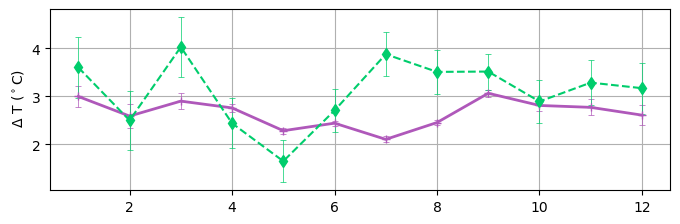

In [5]:
color1='#00CD6C'#green
color2='#AF58BA'#purple
color3='#FFC61E' #yello
color4='#009ADE' #blue
color5='#F28522' #orange
color6='#A0B1BA' #gray
color7='#A6761D'#brown
color8='#FF1F5B' #red
months = np.arange(1, 13)

plt.figure(figsize=(8,8))
ax = plt.subplot(3, 1, 1)
#om, lm=getaverages('t', period, domain)
caps=2.5
capw=0.5
capt=0.5
plt.errorbar(months, results_t['delta85']['ocean'], yerr=results_t['delta85']['ocean_sem'],
             label='Ocean', marker='+', color=color2, linewidth=2,
             capsize=caps, capthick=capt, elinewidth=capw)

plt.errorbar(months, results_t['delta85']['land'], yerr=results_t['delta85']['land_sem'],
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=caps, capthick=capt, elinewidth=capw)
#plt.plot(months, do_85, label='Ocean', marker='+', color=color2)
#plt.plot(months, dl_85, label='Land', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)
plt.ylabel(r' $\Delta$ T ($^\circ \mathrm{C}$)')
plt.grid(True)

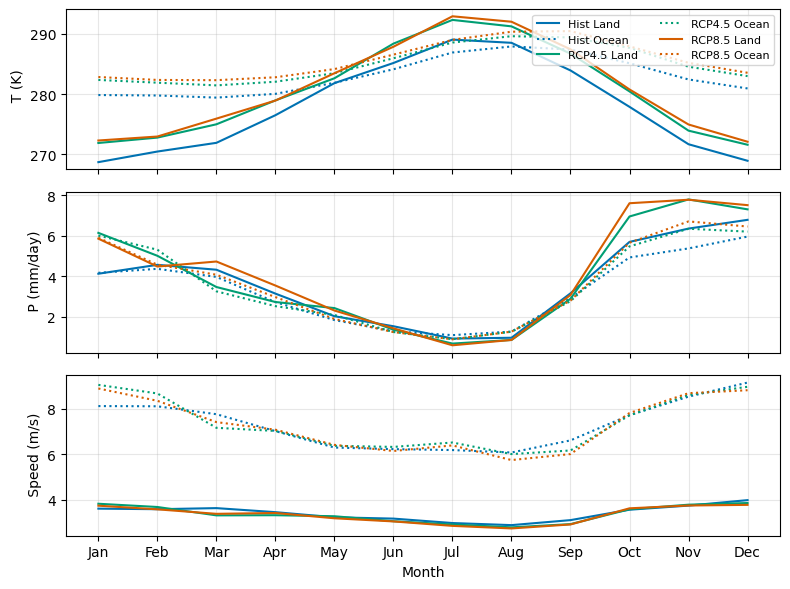

In [6]:
import numpy as np
import matplotlib.pyplot as plt

months = np.arange(1, 13)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']


# ============================================================
# Load results
# ============================================================

t = results_t
pr = results_pr
w = results_wind


# ============================================================
# Colorblind-safe palette (Okabe-Ito style)
# ============================================================

colors = {
    'hist':  '#0072B2',  # blue
    'rcp45': '#009E73',  # green
    'rcp85': '#D55E00'   # vermillion
}


# ============================================================
# Line styles for surface type
# ============================================================

linestyles = {
    'land': '-',
    'ocean': ':'
}


# ============================================================
# Helper function
# ============================================================

def plot_panel(ax, res, title):

    # Historical
    ax.plot(months, res['historical']['land'],
            color=colors['hist'], linestyle=linestyles['land'],
            label='Hist Land')

    ax.plot(months, res['historical']['ocean'],
            color=colors['hist'], linestyle=linestyles['ocean'],
            label='Hist Ocean')

    # RCP4.5
    ax.plot(months, res['rcp45']['land'],
            color=colors['rcp45'], linestyle=linestyles['land'],
            label='RCP4.5 Land')

    ax.plot(months, res['rcp45']['ocean'],
            color=colors['rcp45'], linestyle=linestyles['ocean'],
            label='RCP4.5 Ocean')

    # RCP8.5
    ax.plot(months, res['rcp85']['land'],
            color=colors['rcp85'], linestyle=linestyles['land'],
            label='RCP8.5 Land')

    ax.plot(months, res['rcp85']['ocean'],
            color=colors['rcp85'], linestyle=linestyles['ocean'],
            label='RCP8.5 Ocean')

    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)
    #ax.set_title(title)
    ax.grid(True, alpha=0.3)
        


# ============================================================
# Figure
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)


plot_panel(axes[0], t, 'Temperature')
axes[0].set_ylabel(r'  T (K)')

plot_panel(axes[1], pr, 'Precipitation')
axes[1].set_ylabel(r' P (mm/day)')

plot_panel(axes[2], w, 'Wind')
plt.ylabel(r' Speed (m/s)')
axes[2].set_xlabel('Month')


axes[0].legend(loc='upper right', ncol=2, fontsize=8)

plt.tight_layout()
plt.savefig('seasonal_cycles.png', format='png', bbox_inches='tight',transparent=False,dpi=500)


plt.show()

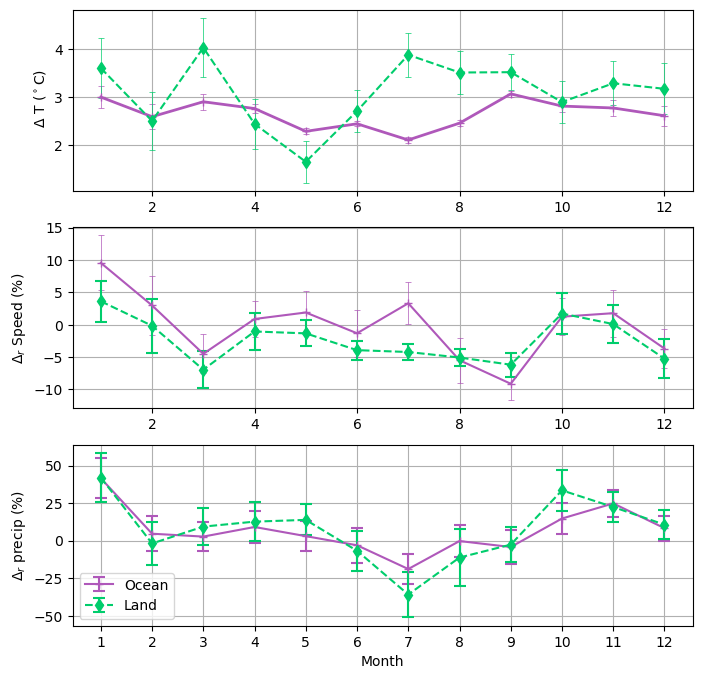

In [7]:
#now plot the seasonal cycle for each 
color1='#00CD6C'#green
color2='#AF58BA'#purple
color3='#FFC61E' #yello
color4='#009ADE' #blue
color5='#F28522' #orange
color6='#A0B1BA' #gray
color7='#A6761D'#brown
color8='#FF1F5B' #red
months = np.arange(1, 13)
plt.figure(figsize=(8,8))
ax = plt.subplot(3, 1, 1)
#om, lm=getaverages('t', period, domain)
caps=2.5
capw=0.5
capt=0.5
plt.errorbar(months, results_t['delta85']['ocean'], yerr=results_t['delta85']['ocean_sem'],
             label='Ocean', marker='+', color=color2, linewidth=2,
             capsize=caps, capthick=capt, elinewidth=capw)

plt.errorbar(months, results_t['delta85']['land'], yerr=results_t['delta85']['land_sem'],
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=caps, capthick=capt, elinewidth=capw)
#plt.plot(months, do_85, label='Ocean', marker='+', color=color2)
#plt.plot(months, dl_85, label='Land', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)
plt.ylabel(r' $\Delta$ T ($^\circ \mathrm{C}$)')
plt.grid(True)

ax = plt.subplot(3, 1, 2)
#om, lm=getaverages('t', period, domain)
plt.errorbar(months, results_wind['delta85']['ocean'], yerr=results_wind['delta85']['ocean_sem'],
             label='Ocean', marker='+', color=color2,
             capsize=caps, capthick=capt, elinewidth=capw)

plt.errorbar(months, results_wind['delta85']['land'], yerr=results_wind['delta85']['land_sem'],
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=4, capthick=1.5, elinewidth=1.5)
#plt.plot(months, do_w_85, label='Ocean', marker='+', color=color2)
#plt.plot(months, dl_w_85, label='Land', linestyle='--', marker='d', color=color1, markeredgecolor=color1)

plt.grid(True)
plt.ylabel(r'$\Delta_r$ Speed (%)')

#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
ax = plt.subplot(3, 1, 3)
#om, lm=getaverages('t', period, domain)
plt.errorbar(months, results_pr['delta85']['ocean'], yerr=results_pr['delta85']['ocean_sem'],
             label='Ocean', marker='+', color=color2,
             capsize=4, capthick=1.5, elinewidth=1.5)

plt.errorbar(months, results_pr['delta85']['land'], yerr=results_pr['delta85']['land_sem'],
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=4, capthick=1.5, elinewidth=1.5)
plt.ylabel(r'$\Delta_r$ precip (%)')

plt.xlabel('Month')
#plt.ylabel(f'Mean fractional change in {var}')
#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
plt.xticks(months)
plt.grid(True)
plt.legend()

In [ ]:
amp_path='/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/MEANS/wind_seasonalAmp_change_rcp45.nc'

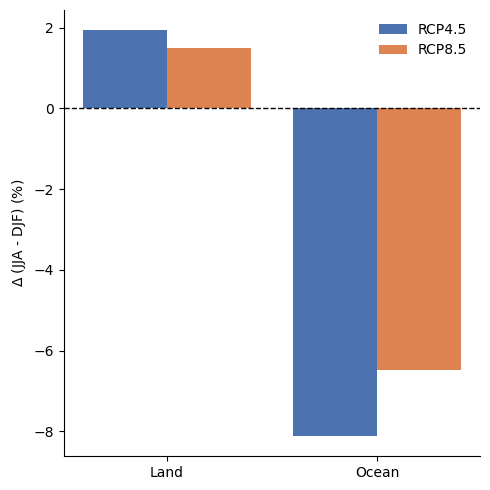

In [9]:
import numpy as np
import matplotlib.pyplot as plt

labels = ['Land', 'Ocean']
x = np.arange(len(labels))*.25
width = 0.1

fig, ax = plt.subplots(figsize=(5, 5))

# Pack data consistently as arrays
rcp45 = np.array([delta45_land_amp, delta45_ocean_amp])
rcp85 = np.array([delta85_land_amp, delta85_ocean_amp])

# Bars
ax.bar(x - width/2, rcp45, width,
       label='RCP4.5', color='#4C72B0')

ax.bar(x + width/2, rcp85, width,
       label='RCP8.5', color='#DD8452')

# Zero reference
ax.axhline(0, linestyle='--', linewidth=1, color='black')

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('$\Delta$ (JJA - DJF) (%)')

ax.legend(frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

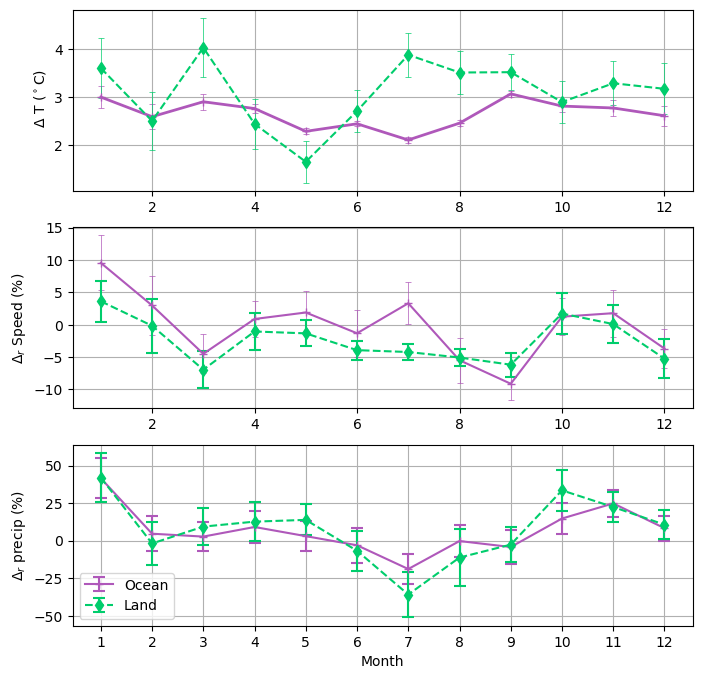

In [10]:
color1='#00CD6C'#green
color2='#AF58BA'#purple
color3='#FFC61E' #yello
color4='#009ADE' #blue
color5='#F28522' #orange
color6='#A0B1BA' #gray
color7='#A6761D'#brown
color8='#FF1F5B' #red
months = np.arange(1, 13)
plt.figure(figsize=(8,8))
ax = plt.subplot(3, 1, 1)
#om, lm=getaverages('t', period, domain)
caps=2.5
capw=0.5
capt=0.5
plt.errorbar(months,results_t['delta85']['ocean'], yerr=results_t['delta85']['ocean_sem'] ,
             label='Ocean', marker='+', color=color2, linewidth=2,
             capsize=caps, capthick=capt, elinewidth=capw)

plt.errorbar(months, results_t['delta85']['land'], yerr=results_t['delta85']['land_sem'],
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=caps, capthick=capt, elinewidth=capw)
#plt.plot(months, do_85, label='Ocean', marker='+', color=color2)
#plt.plot(months, dl_85, label='Land', linestyle='--', marker='d', color=color1,  markeredgecolor=color1)
plt.ylabel(r' $\Delta$ T ($^\circ \mathrm{C}$)')
plt.grid(True)

ax = plt.subplot(3, 1, 2)
#om, lm=getaverages('t', period, domain)
plt.errorbar(months, results_wind['delta85']['ocean'], yerr=results_wind['delta85']['ocean_sem'],
             label='Ocean', marker='+', color=color2,
             capsize=caps, capthick=capt, elinewidth=capw)

plt.errorbar(months, results_wind['delta85']['land'], yerr=results_wind['delta85']['land_sem'],
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=4, capthick=1.5, elinewidth=1.5)
#plt.plot(months, do_w_85, label='Ocean', marker='+', color=color2)
#plt.plot(months, dl_w_85, label='Land', linestyle='--', marker='d', color=color1, markeredgecolor=color1)

plt.grid(True)
plt.ylabel(r'$\Delta_r$ Speed (%)')

#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
ax = plt.subplot(3, 1, 3)
#om, lm=getaverages('t', period, domain)
plt.errorbar(months, results_pr['delta85']['ocean'], yerr=results_pr['delta85']['ocean_sem'],
             label='Ocean', marker='+', color=color2,
             capsize=4, capthick=1.5, elinewidth=1.5)

plt.errorbar(months, results_pr['delta85']['land'], yerr=results_pr['delta85']['land_sem'],
             label='Land', linestyle='--', marker='d', color=color1,
             markeredgecolor=color1,
             capsize=4, capthick=1.5, elinewidth=1.5)
plt.ylabel(r'$\Delta_r$ precip (%)')

plt.xlabel('Month')
#plt.ylabel(f'Mean fractional change in {var}')
#plt.ylabel(f'Monthly Mean Δ ({period} vs hist)')
plt.xticks(months)
plt.grid(True)
plt.legend()

In [11]:
print('annual average warming over land', np.mean(results_t['delta45']['land']), 'water', np.mean(results_t['delta45']['ocean']), ' difference ', np.mean(results_t['delta45']['ocean']-results_t['delta45']['land']))
print('annual average warming over land', np.mean(results_t['delta85']['land']), 'water', np.mean(results_t['delta85']['ocean']), ' difference ', np.mean(results_t['delta85']['ocean']-results_t['delta85']['land']))


annual average warming over land 2.6169057940454272 water 2.0193019882208225  difference  -0.5976038058246047
annual average warming over land 3.097350152510946 water 2.6475856361920953  difference  -0.44976451631885084


5.743728251793414 6.142409188037107
-4.511325338563665 -3.617872648126351
pr [29.08720235 30.17754253] [24.16731254 24.69552628]
-2.597622911940003 -2.301165549747692
wind [21.51045375 13.80140193] [14.47066955 12.88292197]


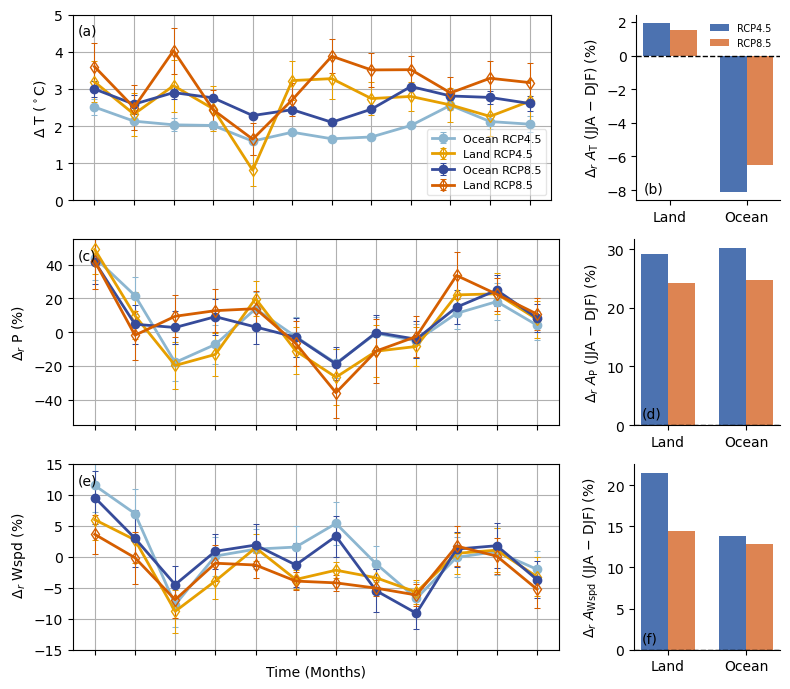

In [16]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import matplotlib.pyplot as plt

subpanel = ['(a)','(b)','(c)','(d)', '(e)', '(f)', 'g','h','i','j']
#subpanel = ['1','2','3', '4', '5','6']

at=0.01
bt=.95
# ============================================================
# Colors (keep your scheme)
# ============================================================

color3 = '#364B9A'  # ocean hist
color2 = '#8CB6D0'  # ocean RCP4.5

color4 = '#D55E00'  # land hist
color1 = '#E69F00'  # land RCP4.5


# ============================================================
# Helper: seasonal cycle error plot
# ============================================================

def plot_error(ax, res):

    caps = 2.5
    capw = 0.75
    capt = 0.75
    lw = 2

    # ------------------------
    # RCP4.5
    # ------------------------
    ax.errorbar(
        months,
        res['delta45']['ocean'],
        yerr=res['delta45']['ocean_sem'],
        label='Ocean RCP4.5',
        marker='o',
        color=color2,
        linewidth=lw,
        capsize=caps,
        capthick=capt,
        elinewidth=capw
    )

    ax.errorbar(
        months,
        res['delta45']['land'],
        yerr=res['delta45']['land_sem'],
        label='Land RCP4.5',
        marker='d',
        linestyle='-',
        color=color1,
        markerfacecolor='None',
        markeredgecolor=color1,
        linewidth=lw,
        capsize=caps,
        capthick=capt,
        elinewidth=capw
    )

    # ------------------------
    # RCP8.5
    # ------------------------
    ax.errorbar(
        months,
        res['delta85']['ocean'],
        yerr=res['delta85']['ocean_sem'],
        label='Ocean RCP8.5',
        marker='o',
        color=color3,
        linewidth=lw,
        capsize=caps,
        capthick=capt,
        elinewidth=capw
    )

    ax.errorbar(
        months,
        res['delta85']['land'],
        yerr=res['delta85']['land_sem'],
        label='Land RCP8.5',
        marker='d',
        linestyle='-',
        color=color4,
        markerfacecolor='None',
        markeredgecolor=color4,
        linewidth=lw,
        capsize=caps,
        capthick=capt,
        elinewidth=capw
    )


# ============================================================
# Figure
# ============================================================

plt.figure(figsize=(8, 7))
ax = plt.subplot(3, 1, 1)

plot_error(ax, results_t)

ax.set_ylabel(r'$\Delta $ T ($^\circ$C)')
ax.grid(True)
ax.set_xticks(months)
ax.set_xticklabels([])
ax.legend(fontsize=8, framealpha=0.5)

ax.set_ylim([0, 5])



divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='30%', pad=0.85)


# ------------------------------------------------------------
# Relative seasonal amplitude change
# ------------------------------------------------------------
labels = ['Land', 'Ocean']
x = np.arange(len(labels))
width = 0.35
delta45_land_amp, delta45_ocean_amp, delta85_land_amp,   delta85_ocean_amp = getAmps(results_t)
# extract amplitudes from results dict
rcp45_amp = np.array([
    delta45_land_amp,
    delta45_ocean_amp
])

rcp85_amp = np.array([
    delta85_land_amp,
    delta85_ocean_amp
])

# bar plots
cax.bar(x - width/2, rcp45_amp,
        width,
        label='RCP4.5',
        color='#4C72B0')

cax.bar(x + width/2, rcp85_amp,
        width,
        label='RCP8.5',
        color='#DD8452')

# zero line
cax.axhline(0, linestyle='--', linewidth=1, color='black')

# formatting
cax.set_xticks(x)
cax.set_xticklabels(labels)
cax.set_ylabel('$\Delta_r$ $A_{\mathrm{T}}$ (JJA − DJF) (%)')

cax.legend(frameon=False, fontsize=7)

cax.spines['top'].set_visible(False)
cax.spines['right'].set_visible(False)


# inset label (optional)
cax.text(
    0.05, 0.1, '(b)',
    transform=cax.transAxes,
    va='top'
)
ax.text(at, bt, subpanel[0], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)

##################################
ax = plt.subplot(3, 1, 2)

plot_error(ax, results_pr)

ax.grid(True)
ax.set_xticks(months)
ax.set_xticklabels([])
#ax.legend(fontsize=8, framealpha=0.5)
plt.ylabel(r'$\Delta_r$ P (%)')

plt.ylim([-55,55])



divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='30%', pad=0.75)


# ------------------------------------------------------------
# Relative seasonal amplitude change
# ------------------------------------------------------------
labels = ['Land', 'Ocean']
x = np.arange(len(labels))
width = 0.35
delta45_land_amp, delta45_ocean_amp, delta85_land_amp,   delta85_ocean_amp = getAmps(results_pr)
# extract amplitudes from results dict
rcp45_amp = np.array([
    delta45_land_amp,
    delta45_ocean_amp
])

rcp85_amp = np.array([
    delta85_land_amp,
    delta85_ocean_amp
])
print('pr', rcp45_amp,rcp85_amp)

# bar plots
cax.bar(x - width/2, rcp45_amp,
        width,
        label='RCP4.5',
        color='#4C72B0')

cax.bar(x + width/2, rcp85_amp,
        width,
        label='RCP8.5',
        color='#DD8452')

# zero line
cax.axhline(0, linestyle='--', linewidth=1, color='black')

# formatting
cax.set_xticks(x)
cax.set_xticklabels(labels)
cax.set_ylabel('$\Delta_r$ $A_{\mathrm{P}}$ (JJA − DJF) (%)')

#cax.legend(frameon=False, fontsize=7)

cax.spines['top'].set_visible(False)
cax.spines['right'].set_visible(False)


# inset label (optional)
cax.text(
    0.05, 0.1, '(d)',
    transform=cax.transAxes,
    va='top'
)
ax.text(at, bt, subpanel[2], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
###############################
ax = plt.subplot(3, 1, 3)


plot_error(ax, results_wind)

ax.grid(True)
ax.set_xticks(months)
ax.set_xticklabels([])
#ax.legend(fontsize=8, framealpha=0.5)
plt.xticks(months)
plt.ylabel(r' $\Delta_r$ Wspd (%)')
plt.xlabel('Time (Months)')


plt.ylim([-15,15])


divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='30%', pad=0.75)


# ------------------------------------------------------------
# Relative seasonal amplitude change
# ------------------------------------------------------------
labels = ['Land', 'Ocean']
x = np.arange(len(labels))
width = 0.35
delta45_land_amp, delta45_ocean_amp, delta85_land_amp,   delta85_ocean_amp = getAmps(results_wind)
# extract amplitudes from results dict
rcp45_amp = np.array([
    delta45_land_amp,
    delta45_ocean_amp
])

rcp85_amp = np.array([
    delta85_land_amp,
    delta85_ocean_amp
])
print('wind', rcp45_amp,rcp85_amp)
# bar plots
cax.bar(x - width/2, rcp45_amp,
        width,
        label='RCP4.5',
        color='#4C72B0')

cax.bar(x + width/2, rcp85_amp,
        width,
        label='RCP8.5',
        color='#DD8452')

# zero line
cax.axhline(0, linestyle='--', linewidth=1, color='black')

# formatting
cax.set_xticks(x)
cax.set_xticklabels(labels)
cax.set_ylabel('$\Delta_r$ $A_{\mathrm{Wspd}}$ (JJA − DJF) (%)')

#cax.legend(frameon=False, fontsize=7)

cax.spines['top'].set_visible(False)
cax.spines['right'].set_visible(False)


# inset label (optional)
cax.text(
    0.05, 0.1, '(f)',
    transform=cax.transAxes,
    va='top'
)
ax.text(at, bt, subpanel[4], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)

plt.savefig('Regional_averages_relative.png', format='png', bbox_inches='tight',transparent=False,dpi=500)


plt.tight_layout()
plt.show()

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import matplotlib.pyplot as plt

subpanel = ['(a)','(b)','(c)','(d)', '(e)', '(f)', 'g','h','i','j']
#subpanel = ['1','2','3', '4', '5','6']

at=0.01
bt=.95
# ============================================================
# Colors (keep your scheme)
# ============================================================

color3 = '#364B9A'  # ocean hist
color2 = '#8CB6D0'  # ocean RCP4.5

color4 = '#D55E00'  # land hist
color1 = '#E69F00'  # land RCP4.5


# ============================================================
# Helper: seasonal cycle error plot
# ============================================================

def plot_error(ax, res):

    caps = 2.5
    capw = 0.75
    capt = 0.75
    lw = 2

    # ------------------------
    # RCP4.5
    # ------------------------
    ax.errorbar(
        months,
        res['delta45']['ocean'],
        yerr=res['delta45']['ocean_sem'],
        label='Ocean RCP4.5',
        marker='o',
        color=color2,
        linewidth=lw,
        capsize=caps,
        capthick=capt,
        elinewidth=capw
    )

    ax.errorbar(
        months,
        res['delta45']['land'],
        yerr=res['delta45']['land_sem'],
        label='Land RCP4.5',
        marker='d',
        linestyle='-',
        color=color1,
        markerfacecolor='None',
        markeredgecolor=color1,
        linewidth=lw,
        capsize=caps,
        capthick=capt,
        elinewidth=capw
    )

    # ------------------------
    # RCP8.5
    # ------------------------
    ax.errorbar(
        months,
        res['delta85']['ocean'],
        yerr=res['delta85']['ocean_sem'],
        label='Ocean RCP8.5',
        marker='o',
        color=color3,
        linewidth=lw,
        capsize=caps,
        capthick=capt,
        elinewidth=capw
    )

    ax.errorbar(
        months,
        res['delta85']['land'],
        yerr=res['delta85']['land_sem'],
        label='Land RCP8.5',
        marker='d',
        linestyle='-',
        color=color4,
        markerfacecolor='None',
        markeredgecolor=color4,
        linewidth=lw,
        capsize=caps,
        capthick=capt,
        elinewidth=capw
    )


# ============================================================
# Figure
# ============================================================

plt.figure(figsize=(8, 7))
ax = plt.subplot(3, 1, 1)

plot_error(ax, results_t)

ax.set_ylabel(r'$\Delta $ T ($^\circ$C)')
ax.grid(True)
ax.set_xticks(months)
ax.set_xticklabels([])
ax.legend(fontsize=8, framealpha=0.5)

ax.set_ylim([0, 5])



divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='30%', pad=0.85)


# ------------------------------------------------------------
# Relative seasonal amplitude change
# ------------------------------------------------------------
labels = ['Land', 'Ocean']
x = np.arange(len(labels))
width = 0.35
delta45_land_amp, delta45_ocean_amp, delta85_land_amp,   delta85_ocean_amp = getAmps(results_t)
# extract amplitudes from results dict
rcp45_amp = np.array([
    -6.96,
    -4.29
])

rcp85_amp = np.array([
    -6.42,
    -2.42
])

# bar plots
cax.bar(x - width/2, rcp45_amp,
        width,
        label='RCP4.5',
        color='#4C72B0')

cax.bar(x + width/2, rcp85_amp,
        width,
        label='RCP8.5',
        color='#DD8452')

# zero line
cax.axhline(0, linestyle='--', linewidth=1, color='black')

# formatting
cax.set_xticks(x)
cax.set_xticklabels(labels)
cax.set_ylabel('$\Delta_r$ $A_{\mathrm{T}}$ (JJA − DJF) (%)')

cax.legend(frameon=False, fontsize=7)

cax.spines['top'].set_visible(False)
cax.spines['right'].set_visible(False)


# inset label (optional)
cax.text(
    0.05, 0.1, '(b)',
    transform=cax.transAxes,
    va='top'
)
ax.text(at, bt, subpanel[0], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)

##################################
ax = plt.subplot(3, 1, 2)

plot_error(ax, results_pr)

ax.grid(True)
ax.set_xticks(months)
ax.set_xticklabels([])
#ax.legend(fontsize=8, framealpha=0.5)
plt.ylabel(r'$\Delta_r$ P (%)')

plt.ylim([-55,55])



divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='30%', pad=0.75)


# ------------------------------------------------------------
# Relative seasonal amplitude change
# ------------------------------------------------------------
labels = ['Land', 'Ocean']
x = np.arange(len(labels))
width = 0.35
delta45_land_amp, delta45_ocean_amp, delta85_land_amp,   delta85_ocean_amp = getAmps(results_pr)
# extract amplitudes from results dict
rcp45_amp = np.array([
    delta45_land_amp,
    delta45_ocean_amp
])

rcp85_amp = np.array([
    delta85_land_amp,
    delta85_ocean_amp
])
print('pr', rcp45_amp,rcp85_amp)

# bar plots
cax.bar(x - width/2, rcp45_amp,
        width,
        label='RCP4.5',
        color='#4C72B0')

cax.bar(x + width/2, rcp85_amp,
        width,
        label='RCP8.5',
        color='#DD8452')

# zero line
cax.axhline(0, linestyle='--', linewidth=1, color='black')

# formatting
cax.set_xticks(x)
cax.set_xticklabels(labels)
cax.set_ylabel('$\Delta_r$ $A_{\mathrm{P}}$ (JJA − DJF) (%)')

#cax.legend(frameon=False, fontsize=7)

cax.spines['top'].set_visible(False)
cax.spines['right'].set_visible(False)


# inset label (optional)
cax.text(
    0.05, 0.1, '(d)',
    transform=cax.transAxes,
    va='top'
)
ax.text(at, bt, subpanel[2], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
###############################
ax = plt.subplot(3, 1, 3)


plot_error(ax, results_wind)

ax.grid(True)
ax.set_xticks(months)
ax.set_xticklabels([])
#ax.legend(fontsize=8, framealpha=0.5)
plt.xticks(months)
plt.ylabel(r' $\Delta_r$ Wspd (%)')
plt.xlabel('Time (Months)')


plt.ylim([-15,15])


divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='30%', pad=0.75)


# ------------------------------------------------------------
# Relative seasonal amplitude change
# ------------------------------------------------------------
labels = ['Land', 'Ocean']
x = np.arange(len(labels))
width = 0.35
# amplitudes from seasonal notebook
rcp45_amp = np.array([
    -6.96,
    -4.29
])

rcp85_amp = np.array([
    -6.42,
    -2.42
])
print('wind', rcp45_amp,rcp85_amp)
# bar plots
cax.bar(x - width/2, rcp45_amp,
        width,
        label='RCP4.5',
        color='#4C72B0')

cax.bar(x + width/2, rcp85_amp,
        width,
        label='RCP8.5',
        color='#DD8452')

# zero line
cax.axhline(0, linestyle='--', linewidth=1, color='black')

# formatting
cax.set_xticks(x)
cax.set_xticklabels(labels)
cax.set_ylabel('$\Delta_r$ $A_{\mathrm{Wspd}}$ (JJA − DJF) (%)')

#cax.legend(frameon=False, fontsize=7)

cax.spines['top'].set_visible(False)
cax.spines['right'].set_visible(False)


# inset label (optional)
cax.text(
    0.05, 0.1, '(f)',
    transform=cax.transAxes,
    va='top'
)
ax.text(at, bt, subpanel[4], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)

plt.savefig('Regional_averages_relative.png', format='png', bbox_inches='tight',transparent=False,dpi=500)


plt.tight_layout()
plt.show()

In [15]:
print(rcp45_amp,rcp85_amp)

[21.51045375 13.80140193] [14.47066955 12.88292197]


In [13]:

# delta should have .month as a dimension
plot_monthly_deltas(delta, land_mask, ocean_mask, title_prefix="temp Change", cmap="Reds")
plt.savefig('Regional_averages_map.png', format='png', bbox_inches='tight',transparent=False,dpi=500)


NameError: name 'plot_monthly_deltas' is not defined

In [ ]:
plt.pcolormesh(ocean_mask)
plt.colorbar()

In [ ]:
plt.pcolormesh(landmask)

In [ ]:
plt.pcolormesh(delta[0,:,:])

In [ ]:
land_avg = delta[0,:,:].where(landmask.data)

In [ ]:
plt.pcolormesh(land_avg[:,:])

In [ ]:
ocean_avg = delta[0,:,:].where(landmask.data==0)